In [1]:
import librosa
print(librosa.__version__)

0.11.0


In [5]:
import librosa.display 
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd


In [23]:

# import librosa
# import IPython.display as ipd
# import time

# examples = librosa.util.list_examples()  

# # safer fallback if version differs
# example_names = ["brahms", "choice", "fishin", "libri1", "libri2", "nutcracker", "trumpet", "vibeace"]

# for name in example_names:
#     audio_path = librosa.ex(name)
#     display(ipd.Audio(audio_path))
#     time.sleep(0.5)



In [27]:
# print(librosa.util.list_examples())

audio_path = librosa.ex("robin")

audio, sr = librosa.load(
    audio_path
)
print(f"{audio}|"
      f"{sr}")

ipd.Audio(audio_path)

[ 5.8678829e-06  7.6058545e-06 -1.4612080e-05 ... -5.2551723e-06
 -1.0614895e-06  2.8505156e-06]|22050


In [32]:
print(len(audio))
duration = librosa.get_duration(
    y=audio,
    sr=sr,
)
print(f"Duration: {duration:.2f}s")

59505
Duration: 2.70s


In [34]:
audio.shape

(59505,)

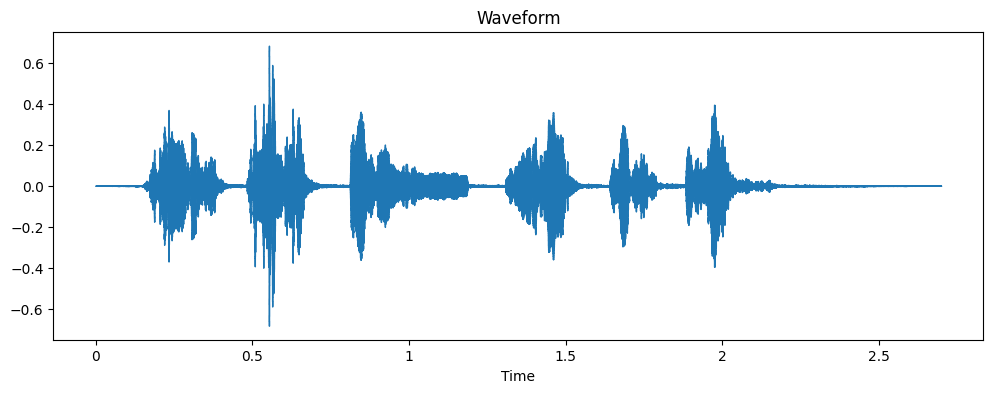

In [35]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(
audio,
sr=sr
)
plt.title(
"Waveform"
)
plt.show()

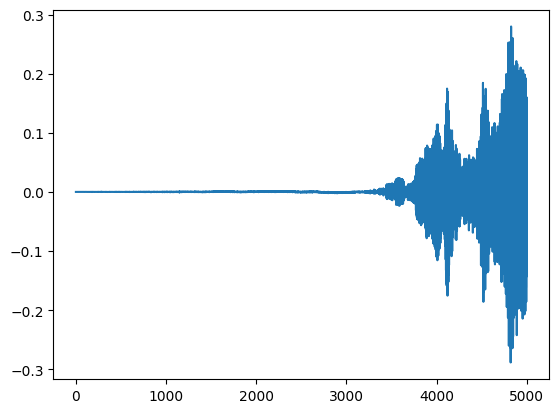

In [36]:
audio[:5000]
plt.plot(
    audio[:5000]
)

# Spectrogram
STFT: Means, Short Time Fourier Transform
This converts:
Waveform to Frequency Information

In [38]:
D = librosa.stft(audio)
#Take Magnitude
D = np.abs(
    librosa.stft(audio)
)
#To Decibel
D_db = librosa.amplitude_to_db(
    D, 
    ref=np.max
)

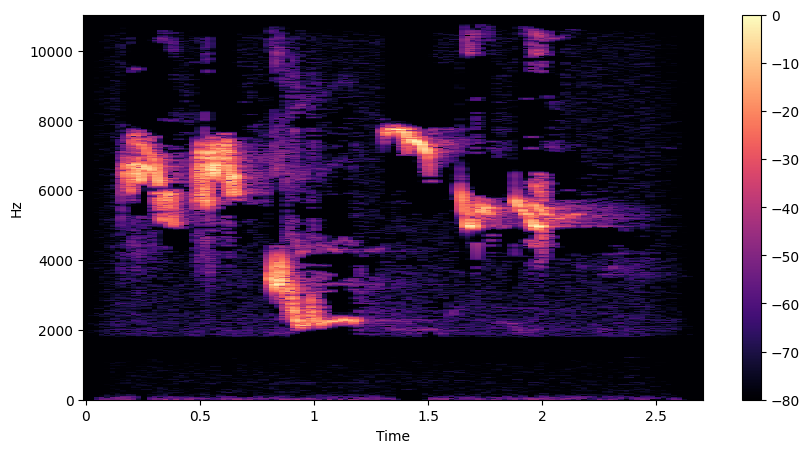

In [41]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(
    D_db,
    sr=sr,
    x_axis='time',
    y_axis='hz'

)
plt.colorbar()
plt.show()

# Mel Spectrogram

In [42]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)



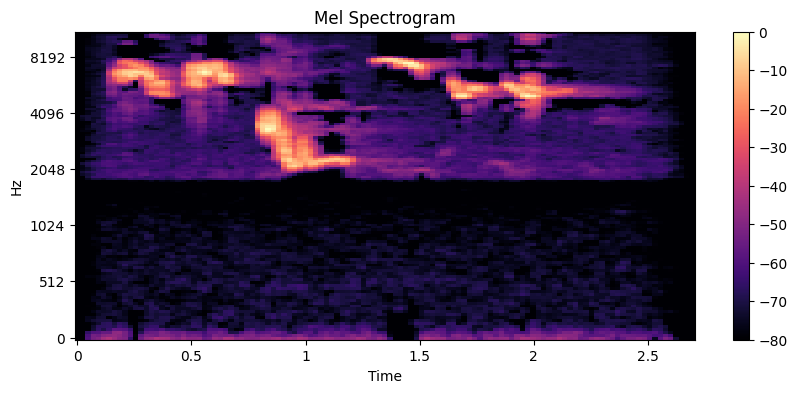

In [44]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis = 'time',
    y_axis = 'mel'
)
plt.colorbar()
plt.title(
    "Mel Spectrogram"
)
plt.show()
